# 🔬 Análise Exploratória de Dados (EDA) — Medical Abstracts TC

**Contexto**: Desenvolvimento de um pipeline MLOps para classificação de textos médicos (NLP) com o *Medical Abstracts TC Corpus* para o Tech Challenge. **Objetivo**: Compreender a volumetria, o balanceamento das classes de condições médicas, o comprimento e a distribuição dos termos nos resumos para desenhar as regras de engenharia de recursos e a vetorização TF-IDF.

# 📦 1. Carregamento e Inspeção Inicial dos Dados

Esta etapa inicial realiza a importação das bibliotecas essenciais e carrega os arquivos do dataset *Medical Abstracts TC* (`train`, `test` e `labels`) armazenados na pasta `data/raw/`. Em seguida, unimos as tabelas para associar os códigos numéricos das classes às suas respectivas descrições textuais.

In [6]:
import os
import pandas as pd

# Definir o caminho correto para a pasta de dados brutos
DATA_RAW_DIR = os.path.join("..", "data", "raw")
print("A iniciar o carregamento dos dados de triagem médica...\n")

# 1. Carregamento do Dataset de Treino
train_path = os.path.join(DATA_RAW_DIR, "medical_tc_train.csv")
if os.path.exists(train_path):
    train_df = pd.read_csv(train_path)
    print("Dataset de treino carregado com sucesso!")
    print(f"Dimensão: {train_df.shape[0]:,} linhas e {train_df.shape[1]} colunas")
else:
    print(f"Arquivo não encontrado em: {train_path}")

# 2. Carregamento do Dataset de Teste
test_path = os.path.join(DATA_RAW_DIR, "medical_tc_test.csv")
if os.path.exists(test_path):
    test_df = pd.read_csv(test_path)
    print("Dataset de teste carregado com sucesso!")
    print(f"Dimensão: {test_df.shape[0]:,} linhas e {test_df.shape[1]} colunas")
else:
    print(f"Arquivo não encontrado em: {test_path}")

# 3. Carregamento do Dicionário de Classes (Labels)
labels_path = os.path.join(DATA_RAW_DIR, "medical_tc_labels.csv")
if os.path.exists(labels_path):
    labels_df = pd.read_csv(labels_path)
    print("Labels de categorias carregados com sucesso!")
    display(labels_df)
else:
    print(f"Arquivo não encontrado em: {labels_path}")

print("\nCarregamento concluído! Pronto para iniciar a EDA.")

A iniciar o carregamento dos dados de triagem médica...

Dataset de treino carregado com sucesso!
Dimensão: 11,550 linhas e 2 colunas
Dataset de teste carregado com sucesso!
Dimensão: 2,888 linhas e 2 colunas
Labels de categorias carregados com sucesso!


,condition_label,condition_name
0,1,neoplasms
1,2,digestive system diseases
2,3,nervous system diseases
3,4,cardiovascular diseases
4,5,general pathological conditions



Carregamento concluído! Pronto para iniciar a EDA.


# 📊 Análise Exploratória e Pré-processamento dos Textos

Esta etapa realiza a análise descritiva da volumetria dos dados textuais, avalia o balanceamento das classes de condições médicas e aplica a função de limpeza e normalização para a vetorização.

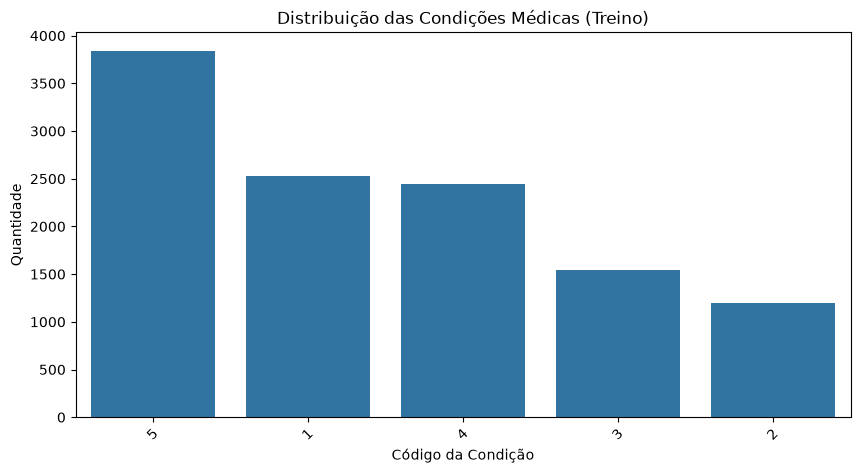

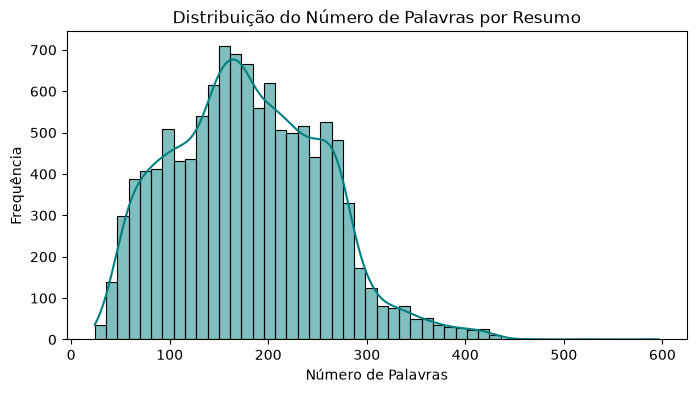

Texto limpo com sucesso! Amostra:


,medical_abstract,clean_abstract
0,Tissue changes around loose prostheses. A cani...,tissue changes around loose prostheses a canin...
1,Neuropeptide Y and neuron-specific enolase lev...,neuropeptide y and neuronspecific enolase leve...


In [7]:
import re
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Distribuição das classes médicas
plt.figure(figsize=(10, 5))
sns.countplot(
    data=train_df, x="condition_label", order=train_df["condition_label"].value_counts().index
)
plt.title("Distribuição das Condições Médicas (Treino)")
plt.xlabel("Código da Condição")
plt.ylabel("Quantidade")
plt.xticks(rotation=45)
plt.show()

# 2. Análise do comprimento dos resumos
train_df["word_count"] = train_df["medical_abstract"].apply(lambda x: len(str(x).split()))
plt.figure(figsize=(8, 4))
sns.histplot(train_df["word_count"], bins=50, kde=True, color="teal")
plt.title("Distribuição do Número de Palavras por Resumo")
plt.xlabel("Número de Palavras")
plt.ylabel("Frequência")
plt.show()


# 3. Função de limpeza de texto para NLP
def clean_text(text: str) -> str:
  """Realiza a limpeza básica de strings textuais."""
  if not isinstance(text, str):
    return ""
  text = text.lower()
  text = re.sub(r"[^a-zá-úà-ùâ-ûãõç\s]", "", text)
  text = re.sub(r"\s+", " ", text).strip()
  return text


train_df["clean_abstract"] = train_df["medical_abstract"].apply(clean_text)
print("Texto limpo com sucesso! Amostra:")
display(train_df[["medical_abstract", "clean_abstract"]].head(2))

# 📉 Análise Detalhada de Frequência e Comprimento de Textos

Esta etapa investiga a distribuição das palavras, o tamanho máximo dos resumos médicos e a identificação de termos mais frequentes (n-grams) para guiar os parâmetros da vetorização.

In [8]:
# Calcular estatísticas avançadas do comprimento dos resumos
print("Estatísticas descritivas completas da contagem de palavras:")
print(train_df["word_count"].describe(percentiles=[0.25, 0.50, 0.75, 0.90, 0.95, 0.99]))

# Identificar o limite ideal para max_length ou max_features analisando o percentil 95
p95_words = int(train_df["word_count"].quantile(0.95))
print(
    f"\n95% dos resumos possuem até {p95_words} palavras. Esse valor é ideal"
    " para definir limites de truncamento se necessário."
)

Estatísticas descritivas completas da contagem de palavras:
count    11550.000000
mean       179.640606
std         76.369776
min         24.000000
25%        122.000000
50%        175.000000
75%        234.000000
90%        275.000000
95%        302.000000
99%        381.510000
max        596.000000
Name: word_count, dtype: float64

95% dos resumos possuem até 302 palavras. Esse valor é ideal para definir limites de truncamento se necessário.


# ☁️ Análise de Termos Frequentes (Top Words)

Esta seção mapeia as palavras mais recorrentes nos resumos médicos limpos para verificar a presença de termos altamente informativos para o classificador.

In [9]:
from collections import Counter

# Unir todos os textos limpos para contagem global de palavras
all_words = " ".join(train_df["clean_abstract"]).split()
word_counts = Counter(all_words)

# Exibir as 20 palavras mais comuns no dataset de treino
print("Top 20 palavras mais frequentes nos resumos médicos:")
for word, freq in word_counts.most_common(20):
  print(f"{word}: {freq:,} ocorrências")

Top 20 palavras mais frequentes nos resumos médicos:
the: 97,788 ocorrências
of: 96,705 ocorrências
and: 64,819 ocorrências
in: 63,135 ocorrências
with: 35,074 ocorrências
a: 34,560 ocorrências
to: 33,993 ocorrências
patients: 27,682 ocorrências
was: 22,732 ocorrências
were: 19,345 ocorrências
for: 17,286 ocorrências
or: 11,784 ocorrências
is: 11,733 ocorrências
that: 11,594 ocorrências
by: 11,493 ocorrências
than: 10,540 ocorrências
from: 8,460 ocorrências
at: 8,013 ocorrências
an: 7,894 ocorrências
this: 7,724 ocorrências


### 🧹 Limpeza e Salvamento do Conjunto de Teste
Esta etapa realiza a limpeza e padronização do conjunto de teste bruto (`medical_tc_test.csv`), aplicando a mesma função de tratamento de texto utilizada no treino e salvando o arquivo resultante na pasta processada (`data/processed/medical_tc_test_clean.csv`).

In [10]:
# Carregar o dataset de teste bruto usando a coluna correta 'medical_abstract'
test_df = pd.read_csv("../data/raw/medical_tc_test.csv")

# Aplicar a limpeza de texto na coluna certa
test_df["clean_abstract"] = test_df["medical_abstract"].apply(clean_text)

# Caminho para salvar o teste processado
processed_test_path = "../data/processed/medical_tc_test_clean.csv"
test_df.to_csv(processed_test_path, index=False)

print(f"Dataset de teste processado salvo com sucesso em: {processed_test_path}")
print(f"Dimensões finais salvas: {test_df.shape}")

Dataset de teste processado salvo com sucesso em: ../data/processed/medical_tc_test_clean.csv
Dimensões finais salvas: (2888, 3)


# 💾 Salvamento dos Dados Processados

Esta etapa exporta a base de dados tratada com a coluna de texto limpo para um arquivo intermediário, garantindo a persistência do trabalho da EDA antes de avançar para a modelagem.

In [11]:
import os

# Certificar que a pasta processada existe
os.makedirs("../data/processed", exist_ok=True)

# Salvar o dataframe de treino limpo
processed_train_path = "../data/processed/medical_tc_train_clean.csv"
train_df.to_csv(processed_train_path, index=False)

print(f"Dataset processado salvo com sucesso em: {processed_train_path}")
print(f"Dimensões finais salvas: {train_df.shape}")

Dataset processado salvo com sucesso em: ../data/processed/medical_tc_train_clean.csv
Dimensões finais salvas: (11550, 4)
